# Financial Analysis

The main jupyter notebook for the analysis of Finnish election candidate finances. *This will, in all likelihood, not remain one file once exploration is complete*. Potential avenues include:
- General regression analysis, observing how much different factors at play (where a candidate got their money from, how they spent it, and other correlatory effects impacted the election results).
    - Previously held electoral experience, financial information
- Isolate anomalies, or people outside of the norm. I.e. Candidate 8 appears to have been very successful even though they spent very little, why is that?
- Who funds who, who spends where based on party, age
- Comparison on effectiveness for different types of ad spending
- Whether self funding is useful/successful

Important drawbacks to remember:
- This information only focuses on the winners of the election, rather then the losers. May be a winner bias, i.e. losers did spend more on self fundraising but those candidates who were already successful used it more effectively.
- Candidates in 2025 who are present in both the municipal and welfare district elections filed one financial report simultaneously. This was not the case before.
- Correlation != causuation and information can make things worse. Obvious but I'm writing it anyways because it must always be kept in mind.



In [2]:
# PREPARING DATA FOR MODEL AND VISUALIZATION
# STEP 1 - Importing Sheets
import pandas as pd
pd.set_option('display.max_columns', None)

kuntavaalit_ehdokas_sarakkeet = list(pd.read_csv("files/Results_title_rows_EN_ehdokas.csv")) # Saved as a list to apply to any candidate voting information, because header wasn't inculuded in the data from the Ministry of Justice.

years_data = {
    2011: {
        'finance': "files/finances/Liite_2_Eduskuntavaalit_2011_VI.csv",
        'results': "files/election_results_by_candidate/e-2011_teat_maa.csv"
    },
    2015: {
        'finance': "files/finances/Liite_4_Eduskuntavaalit_2015_VI.csv",
        'results': "files/election_results_by_candidate/e-2015_teat_maa.csv"
    },
    2019: {
        'finance': "files/finances/Liite_6_Eduskuntavaalit_2019_VI.csv",
        'results': "files/election_results_by_candidate/ekv-2019_teat_maa.csv"
    },
    2023: {
        'finance': "files/finances/Liite_8_Eduskuntavaalit_2023_VI.csv",
        'results': "files/election_results_by_candidate/ekv-2023_teat_maa.csv"
    }
}

def process_year_data(year, finance_path, results_path):
    """Process election data for a specific year."""

    kuntavaalit_rahoitus = pd.read_csv(finance_path, sep=";", quotechar="'", on_bad_lines='warn')
    kuntavaalit_ehdokas = pd.read_csv(results_path, sep=";", on_bad_lines='warn', encoding='latin-1', names=kuntavaalit_ehdokas_sarakkeet, index_col=False)
    
    print(kuntavaalit_rahoitus["Ehdokasnumero"].isna().sum())
    kuntavaalit_rahoitus = kuntavaalit_rahoitus.dropna(subset=["Ehdokasnumero"]) # Handling NAN exceptions
    kuntavaalit_rahoitus["Ehdokasnumero"] = kuntavaalit_rahoitus["Ehdokasnumero"].astype(int)
    print(kuntavaalit_rahoitus["Ehdokasnumero"].isna().sum())

    
    kuntavaalit_ehdokas["LR_cand-id"] = (
        kuntavaalit_ehdokas["Candidate number"].astype(str).str.strip() + "-" +
        kuntavaalit_ehdokas["Name of a municipality/electoral district/voting area in Finnish"].str.strip() + "-" + kuntavaalit_ehdokas["Area type"]
    )
    kuntavaalit_rahoitus["LR_cand-id"] = (
        kuntavaalit_rahoitus["Ehdokasnumero"].astype(str).str.strip() + "-" +
        kuntavaalit_rahoitus["Vaalipiiri/Kunta"].str.strip() + "-V"
    ) # We need to merge the candidates, but the IDs are per municipality. I create a new ID to ensure uniqueness across the whole data. UPDATE Oct 31st - realized that candidates were being duplicated because the ID matched with both the municipality and more specific voting district. Adding area type (K) to specify that it's searching for the municipality only.

    kuntavaalit_yhteensä = kuntavaalit_rahoitus.merge(kuntavaalit_ehdokas, how="left", on="LR_cand-id") # Merged on the left since a lot of duplicate data in the Ministry of Justice and I only want the candidates who actually have fundraising data of some kind (i.e. candidates in more then one municipality with no votes? My look suggests that they are only given the votes where they actually ran, and assumedly the financial data with self select, but INVESTIGATE MORE).

    kuntavaalit_yhteensä['year'] = year # Year column for classification later

    kuntavaalit_yhteensä['LR_cand-id'] = (kuntavaalit_yhteensä['LR_cand-id'] + "-" + str(year)) # For uniqueness when combining the entire dataset.

    return kuntavaalit_yhteensä

all_years_data = []
for year, paths in years_data.items():
    print(f"Processing {year}...")
    year_df = process_year_data(year, paths['finance'], paths['results'])
    all_years_data.append(year_df)

kuntavaalit_yhteensä_all = pd.concat(all_years_data, ignore_index=True)
print(f"In total, there were {len(all_years_data[0])} candidates recorded from 2012; {len(all_years_data[1])} from 2017; {len(all_years_data[2])} from 2021; and {len(all_years_data[3])} from 2025.")

Processing 2011...


FileNotFoundError: [Errno 2] No such file or directory: 'files/election_results_by_candidate/e-2011_teat_maa.csv'

In [5]:
import copy
import numpy as np

# STEP 2 - Creating joint analysis sheet

parliamentary_macro_results = pd.read_csv("files/outputs/parliamentary_macro_per_year.csv") # Getting municipal macro results for analysis purposes.

## Creating an incumbency single column value
def determine_incumbency(row):
    """Determine the highest level of incumbency for a candidate."""
    if row["Member of Parliament"] == "1":
        return "European Parliament"
    elif row["Member of the European Parliament"] == "1":
        return "Parliament"
    elif row["Municipal councillor"] == "1":
        return "Municipal"
    elif row["County councillor"] == "1":
        return "County"
    else:
        return "None"

def clean_numeric_columns(df, columns):
    """Convert columns with comma decimals to numeric type."""
    for col in columns: # NOTE: Currently will crash if it runs into a non string in a column
        df[col] = df[col].str.replace(" ", "").str.replace(",", ".")
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def set_minor_values(df, column):
    df[column]


kuntavaalit_yhteensä_all_t = copy.deepcopy(kuntavaalit_yhteensä_all)

kuntavaalit_yhteensä_all_t["LR_incumbency"] = kuntavaalit_yhteensä_all_t.apply(
    determine_incumbency, axis=1
)

kuntavaalit_yhteensä_all_t = kuntavaalit_yhteensä_all_t.rename(columns={
    'Percentage (%) of the total number of votes': 'vote_prct',
    'Vaalikampanjan kulut yhteensa': 'total_expenses',
    "Vaalikampanjan rahoitus yhteensa": "total_raised",
    "Vaalipiiri/Kunta": "municipality",
    "Age on election day": "age",
    "Puolue": "party",
    "2.1 Rahoitus sisaltaa omia varoja yhteensa": "tf_self_funding",
    "2.2 Rahoitus sisaltaa ehdokkaan ja tukiryhman ottamia lainoja yhteensa": "tf_loans",
    "2.3 Rahoitus sisaltaa yksityishenkiloilta saatua tukea yhteensa": "tf_private_individuals",
    "2.4 Rahoitus sisaltaa yrityksilta saatua tukea yhteensa": "tf_companies",
    "2.5 Rahoitus sisaltaa puolueelta saatua tukea yhteensa": "tf_party",
    "2.6 Rahoitus sisaltaa puolueyhdistyksilta saatua tukea yhteensa": "tf_party_associations",
    "2.7 Rahoitus sisaltaa muilta tahoilta saatua tukea yhteensa": "tf_others",
    "Sanoma- ilmaisjakelu- ja aikakauslehdet": "sl_newspapers_periodicals",
    "Radio": "sl_radio",
    "Televisio": "sl_television",
    "Tietoverkot": "sl_information_networks",
    "Muut viestintavalineet": "sl_other_media",
    "Ulkomainonta": "sl_outdoor_advertising",
    "Vaalilehtien esitteiden ja muun painetun materiaalin hankinta": "sl_printed_material_procurement",
    "Mainonnan suunnittelu": "sl_advertising_planning",
    "Vaalitilaisuudet": "sl_rallies",
    "Vastikeellisen tuen hankintakulut": "sl_fundraising",
    "Muut kulut": "sl_other"
}) # Renaming for model calc. Doesn't like spaces/special characters

main_parties = ["SDP", "KOK", "VAS", "VIHR", "KD", "KESK", "KOK", "PS"]
kuntavaalit_yhteensä_all_t['party'] = np.where(
    kuntavaalit_yhteensä_all_t['party'].isin(main_parties),
    kuntavaalit_yhteensä_all_t['party'],
    'Other'
) # We want to make sure that the small parties are not blurring the information or making sorting difficult.

kuntavaalit_yhteensä_all_t = clean_numeric_columns(kuntavaalit_yhteensä_all_t, ["total_raised", "total_expenses", "tf_self_funding", "tf_loans", "tf_private_individuals", "tf_companies", "tf_party", "tf_party_associations", "tf_others", "sl_newspapers_periodicals", "sl_radio", "sl_television", "sl_information_networks", "sl_other_media", "sl_outdoor_advertising", "sl_printed_material_procurement", "sl_advertising_planning", "sl_rallies", "sl_fundraising", "sl_other"])

kuntavaalit_yhteensä_all_t["own_fund_prct"] = kuntavaalit_yhteensä_all_t["tf_self_funding"]/kuntavaalit_yhteensä_all_t["total_raised"] # Testing out in the regression analysis whether a % of own funding for campaigns is statistically relevant
kuntavaalit_yhteensä_all_t["full_name"] = kuntavaalit_yhteensä_all_t["Etunimet"] + " " + kuntavaalit_yhteensä_all_t["Sukunimi"] # I want to be able to easily call the full names of people
kuntavaalit_yhteensä_all_t["total_raised_per_1k"] = kuntavaalit_yhteensä_all_t["total_raised"]/1000 # Better way to see the effects on the regression analysis
kuntavaalit_yhteensä_all_t["vote_prct"] = kuntavaalit_yhteensä_all_t["vote_prct"]/10 # Vote percent is raised by a factor of 10
# kuntavaalit_yhteensä_all_t["multi_election"] = kuntavaalit_yhteensä_all_t["multi_election"].fillna("Ei") # 2025 election had candidates file financial reporting when running in two elections. I want to isolate this effect from the acutal effect of money on one election.

# Municipality NUM candidates matching
lookup = parliamentary_macro_results.set_index(
    ['Name of a municipality/electoral district/voting area in Finnish', 'Year']
)['num_candidates'].to_dict()

# print(lookup)

kuntavaalit_yhteensä_all_t['num_candidates_in_municipality'] = kuntavaalit_yhteensä_all_t.apply(
    lambda row: lookup.get((row['municipality'].strip(), row['year']), None), axis=1
)

kuntavaalit_yhteensä_all_t["normalized_vote_prct"] = kuntavaalit_yhteensä_all_t['vote_prct'] * kuntavaalit_yhteensä_all_t['num_candidates_in_municipality'] / max(kuntavaalit_yhteensä_all_t['num_candidates_in_municipality']) # For display purposes. Candidates in smaller districts will have their "ability" overrepresented.

# Creating dummies
dummies_incumbency = pd.get_dummies(kuntavaalit_yhteensä_all_t['LR_incumbency'], prefix='incumbency')
# dummies_multi = pd.get_dummies(kuntavaalit_yhteensä_all_t['multi_election'], prefix='multi_election')

kuntavaalit_yhteensä_all_t = pd.concat([kuntavaalit_yhteensä_all_t, dummies_incumbency], axis=1)

print(len(kuntavaalit_yhteensä_all_t))
kuntavaalit_yhteensä_all_t = kuntavaalit_yhteensä_all_t.dropna(subset=['total_raised'])
kuntavaalit_yhteensä_all_t = kuntavaalit_yhteensä_all_t.drop(kuntavaalit_yhteensä_all_t[np.isinf(kuntavaalit_yhteensä_all_t['own_fund_prct'])].index)
kuntavaalit_yhteensä_all_t_helsinki = kuntavaalit_yhteensä_all_t.drop(kuntavaalit_yhteensä_all_t[kuntavaalit_yhteensä_all_t['municipality']!="Helsinki"].index)
kuntavaalit_yhteensä_all_t_helsinki_2025 = kuntavaalit_yhteensä_all_t_helsinki.drop(kuntavaalit_yhteensä_all_t_helsinki[kuntavaalit_yhteensä_all_t_helsinki['year']!=2025].index)
kuntavaalit_yhteensä_all_t_2025 = kuntavaalit_yhteensä_all_t.drop(kuntavaalit_yhteensä_all_t[kuntavaalit_yhteensä_all_t['year']!=2025].index)
print(len(kuntavaalit_yhteensä_all_t))

# print(municipal_macro_results["total_votes"].describe())
print(kuntavaalit_yhteensä_all_t["Total number of votes"].describe())

# display(parliamentary_macro_results)
display(kuntavaalit_yhteensä_all_t)
# # means = kuntavaalit_yhteensä_2025.groupby('LR_incumbency')['total_expenses'].mean()
# print(means)
# print(kuntavaalit_yhteensä["Total number of votes"].sum())
# print(kuntavaalit_yhteensä_all_t[kuntavaalit_yhteensä_all_t["LR_cand-id"]=="216-Helsinki"])


1102
1102
count     1102.000000
mean      6034.003630
std       4118.923979
min        388.000000
25%       3839.750000
50%       5183.000000
75%       6989.250000
max      43437.000000
Name: Total number of votes, dtype: float64


,Ehdokasnumero,Etunimet,Sukunimi,Arvo/ammatti/tehtava,municipality,party,Ehdokkaan mahdollisen tukiryhman nimi,total_expenses,sl_newspapers_periodicals,sl_radio,sl_television,sl_information_networks,sl_other_media,sl_outdoor_advertising,sl_printed_material_procurement,sl_advertising_planning,sl_rallies,sl_fundraising,sl_other,total_raised,tf_self_funding,tf_loans,tf_private_individuals,"2.3 Ei sisalla yhtaan vahintaan 1500 euron tukisuoritusta yksityishenkilolta (""x"")",2.3 Rahoitus sisaltaa yksityishenkiloilta saatua tukea yhteensa lisatietokentan teksti,tf_companies,"2.4 Ei sisalla yhtaan vahintaan 1500 euron tukisuoritusta yrityksilta (""x"")",2.4 Rahoitus sisaltaa yrityksilta saatua tukea yhteensa lisatietokentan teksti,tf_party,"2.5 Ei sisalla yhtaan vahintaan 1500 euron tukisuoritusta puolueelta (""x"")",2.5 Rahoitus sisaltaa puolueelta saatua tukea yhteensa lisatietokentan teksti,tf_party_associations,"2.6 Ei sisalla yhtaan vahintaan 1500 euron tukisuoritusta puolueyhdistyksilta (""x"")",2.6 Rahoitus sisaltaa puolueyhdistyksilta saatua tukea yhteensa lisatietokentan teksti,tf_others,"2.7 Ei sisalla yhtaan vahintaan 1500 euron tukisuoritusta muilta tahoilta (""x"")",2.7 Rahoitus sisaltaa muilta tahoilta saatua tukea yhteensa lisatietokentan teksti,2.8 Rahoitus sisaltaa valitettya tukea yhteensa,E. vapaaehtoinen erittely,LR_cand-id,Election type,Electoral district / county number,Municipality number,Area type,Voting area identifier,Abbreviation for an electoral district / a county in Finnish,Abbreviation for an electoral district / a county in Swedish,Permanent party identifier,Standard party number,List order number,Electoral alliance number,Abbreviated name of a political party/group in Finnish,Abbreviated name of a political party/group in Swedish,Abbreviated name of a political party/group in English,Candidate number,Name of a municipality/electoral district/voting area in Finnish,Name of a municipality/electoral district/voting area in Swedish,A person’s first name,A person’s last name,Gender,age,Profession,Code for place of residence,The name of a place of residence in Finnish,The name of a place of residence in Swedish,Candidate’s language,Member of the European Parliament,Member of Parliament,Municipal councillor,County councillor,Abbreviated name of the first comparison election,Number of votes in the first comparison election,Number of votes cast in advance,Number of votes cast on election day,Total number of votes,Percentage (%) of votes cast in advance,Percentage (%) of votes on election day,vote_prct,Elected information,Comparative index,Position,Final position,Calculation status,Calculation phase,Latest update,year,Saapumispaiva,Muokkauspaiva,LR_incumbency,own_fund_prct,full_name,total_raised_per_1k,num_candidates_in_municipality,normalized_vote_prct,incumbency_County,incumbency_European Parliament,incumbency_Municipal,incumbency_None,incumbency_Parliament
0,161,Laila Margit,Koskela,sairaanhoitaja ...,Pirkanmaan vaalipiiri,Other,Laila Koskelan tukiyhdistys,4640.39,3591.33,NaN,NaN,39.00,NaN,295.06,405.00,NaN,310.00,NaN,NaN,4640.39,4222.09,NaN,118.3,X,NaN,NaN,,NaN,NaN,,NaN,300.00,X,NaN,NaN,,NaN,NaN,NaN,161-Pirkanmaan vaalipiiri-V-2011,E,7,***,V,****,PIR,BIR,23,8,13,11,PS,SAF,TF,161,Pirkanmaan vaalipiiri,Birkalands valkrets,Laila ...,Koskela ...,2,62,sairaanhoitaja ...,837,Tampere,Tammerfors,,,,1,,,0000000,5063,4109,9172,38,29,3.3,1,57844000,3,3,V,T,20131212175905,2011,NaN,NaN,Municipal,0.909857,Laila Margit Koskela ...,4.64039,207,1.388415,False,False,True,False,False
1,163,Heikki Pekka,Luoto,ohjelmistosuunnittelija ...,Pirkanmaan vaalipiiri,Other,NaN,5795.25,3936.00,0.0,0.00,147.60,0.0,279.69,1370.50,0.00,40.00,0.00,21.46,5850.51,3456.61,0.0,2143.9,X,NaN,0.0,X,NaN,0.0,X,NaN,0.00,X,NaN,250.00,X,NaN,0,NaN,163-Pirkanmaan vaalipiiri-V-2011,E,7,***,V,****,PIR,BIR,23,8,13,11,PS,SAF,TF,163,Pirkanmaan vaalipiiri,Birkalands valkrets,Heikki ...,Luoto ...,1,41,ohjelmistosuunnittelija ...,837,Tampere,Tammerfors,,,,1,,,0

In [107]:
from sklearn.impute import SimpleImputer
kuntavaalit_yhteensä_clustering = kuntavaalit_yhteensä_all_t.drop(columns=["A person’s first name", "A person’s last name", "LR_cand-id", "Election type", "Municipality number", "Area type", "Voting area identifier", "Abbreviation for an electoral district / a county in Finnish", "Abbreviation for an electoral district / a county in Swedish", "Standard party number", "Permanent party identifier", "Abbreviated name of a political party/group in Finnish", "Abbreviated name of a political party/group in Swedish", "Abbreviated name of a political party/group in English", "Name of a municipality/electoral district/voting area in Finnish", "Name of a municipality/electoral district/voting area in Swedish", "The name of a place of residence in Swedish", "Calculation status", "Calculation phase", "Latest update", "Saapumispaiva", "Muokkauspaiva", "full_name", "total_raised_per_1k", "normalized_vote_prct", "incumbency_County", "incumbency_European Parliament", "incumbency_Municipal", "incumbency_None", "incumbency_Parliament", "County councillor", "Municipal councillor", "Member of Parliament", "Member of the European Parliament", "Profession", "Code for place of residence", "Position", "Ehdokasnumero", "Electoral district / county number", "List order number", "Electoral alliance number", "Abbreviated name of the first comparison election", "Number of votes in the first comparison election", "Arvo/ammatti/tehtava", "2.7 Rahoitus sisaltaa muilta tahoilta saatua tukea yhteensa lisatietokentan teksti", "2.6 Rahoitus sisaltaa puolueyhdistyksilta saatua tukea yhteensa lisatietokentan teksti", "2.5 Rahoitus sisaltaa puolueelta saatua tukea yhteensa lisatietokentan teksti", "2.4 Rahoitus sisaltaa yrityksilta saatua tukea yhteensa lisatietokentan teksti", "2.3 Rahoitus sisaltaa yksityishenkiloilta saatua tukea yhteensa lisatietokentan teksti", "E. vapaaehtoinen erittely", "Candidate’s language", "own_fund_prct"])
print(len(kuntavaalit_yhteensä_clustering["2.3 Ei sisalla yhtaan vahintaan 1500 euron tukisuoritusta yksityishenkilolta (\"x\")"].unique()))

# Information was removed from the dataset based on three basic premises:
# - the information only has one result, and therefore provides no value (Municipality Number being "***")
# - the information is a duplicate of another column
# - the information is election administrative and is to noisy for the goal of understanding the effect of money
# - The information is to unique

categorical_columns = ["2.3 Ei sisalla yhtaan vahintaan 1500 euron tukisuoritusta yksityishenkilolta (\"x\")", "2.4 Ei sisalla yhtaan vahintaan 1500 euron tukisuoritusta yrityksilta (\"x\")", "2.5 Ei sisalla yhtaan vahintaan 1500 euron tukisuoritusta puolueelta (\"x\")", "2.6 Ei sisalla yhtaan vahintaan 1500 euron tukisuoritusta puolueyhdistyksilta (\"x\")", "2.7 Ei sisalla yhtaan vahintaan 1500 euron tukisuoritusta muilta tahoilta (\"x\")", "Ehdokkaan mahdollisen tukiryhman nimi"]
kuntavaalit_yhteensä_clustering = kuntavaalit_yhteensä_clustering.drop(columns=categorical_columns)

# For numerical columns
numerical_columns = ["sl_radio", "sl_television", "sl_information_networks", "sl_other_media", "sl_outdoor_advertising", "sl_printed_material_procurement", "sl_advertising_planning", "sl_rallies", "sl_fundraising", "sl_other", "tf_loans", "tf_private_individuals", "tf_companies", "tf_party", "tf_party_associations", "tf_others", "2.8 Rahoitus sisaltaa valitettya tukea yhteensa", "tf_self_funding", "sl_newspapers_periodicals"]
num_imputer = SimpleImputer(strategy='constant', fill_value="0")  # or 'mean'
kuntavaalit_yhteensä_clustering[numerical_columns] = num_imputer.fit_transform(kuntavaalit_yhteensä_clustering[numerical_columns])

kuntavaalit_yhteensä_clustering[numerical_columns] = kuntavaalit_yhteensä_clustering[numerical_columns].astype(str)
kuntavaalit_yhteensä_clustering[numerical_columns] = kuntavaalit_yhteensä_clustering[numerical_columns].apply(
    lambda col: col.str.replace(',', '.', regex=False)
)
kuntavaalit_yhteensä_clustering[numerical_columns] = kuntavaalit_yhteensä_clustering[numerical_columns].astype(float)

# # For categorical columns
# categorical_columns = ["2.3 Ei sisalla yhtaan vahintaan 1500 euron tukisuoritusta yksityishenkilolta (\"x\")", "2.4 Ei sisalla yhtaan vahintaan 1500 euron tukisuoritusta yrityksilta (\"x\")", "2.5 Ei sisalla yhtaan vahintaan 1500 euron tukisuoritusta puolueelta (\"x\")", "2.6 Ei sisalla yhtaan vahintaan 1500 euron tukisuoritusta puolueyhdistyksilta (\"x\")", "2.7 Ei sisalla yhtaan vahintaan 1500 euron tukisuoritusta muilta tahoilta (\"x\")"]
# cat_imputer = SimpleImputer(strategy='most_frequent')
# kuntavaalit_yhteensä_clustering[categorical_columns] = cat_imputer.fit_transform(kuntavaalit_yhteensä_clustering[categorical_columns])

# kuntavaalit_yhteensä_clustering["own_fund_prct"] = kuntavaalit_yhteensä_clustering[]/kuntavaalit_yhteensä_clustering[]
# kuntavaalit_yhteensä_clustering = kuntavaalit_yhteensä_clustering.dropna()
# null_data = [kuntavaalit_yhteensä_clustering[kuntavaalit_yhteensä_clustering.isnull().any(axis=1)]]
kuntavaalit_yhteensä_clustering = kuntavaalit_yhteensä_clustering[kuntavaalit_yhteensä_clustering["party"]=="SDP"]
print(kuntavaalit_yhteensä_clustering.dtypes)
display(kuntavaalit_yhteensä_clustering)

3
Etunimet                                            object
Sukunimi                                            object
municipality                                        object
party                                               object
total_expenses                                     float64
sl_newspapers_periodicals                          float64
sl_radio                                           float64
sl_television                                      float64
sl_information_networks                            float64
sl_other_media                                     float64
sl_outdoor_advertising                             float64
sl_printed_material_procurement                    float64
sl_advertising_planning                            float64
sl_rallies                                         float64
sl_fundraising                                     float64
sl_other                                           float64
total_raised                                       flo

,Etunimet,Sukunimi,municipality,party,total_expenses,sl_newspapers_periodicals,sl_radio,sl_television,sl_information_networks,sl_other_media,sl_outdoor_advertising,sl_printed_material_procurement,sl_advertising_planning,sl_rallies,sl_fundraising,sl_other,total_raised,tf_self_funding,tf_loans,tf_private_individuals,tf_companies,tf_party,tf_party_associations,tf_others,2.8 Rahoitus sisaltaa valitettya tukea yhteensa,Candidate number,Gender,age,The name of a place of residence in Finnish,Number of votes cast in advance,Number of votes cast on election day,Total number of votes,Percentage (%) of votes cast in advance,Percentage (%) of votes on election day,vote_prct,Elected information,Comparative index,Final position,year,LR_incumbency,num_candidates_in_municipality
282,Tuula,Haatainen,Helsingin vaalipiiri,SDP,29782.00,13541.00,0.0,10015.00,300.00,124.0,1700.00,1934.00,0.00,630.00,370.0,1168.00,29782.00,23402.00,0.0,1030.00,0.0,300.0,1000.00,4050.00,0.0,136,2,55,Helsinki,3301,3361,6662,22,16,1.9,1,18624667,16,2015,None,269
295,Eero,Heinäluoma,Helsingin vaalipiiri,SDP,50931.07,8646.69,0.0,13436.64,989.19,740.6,12950.00,4696.30,3752.81,2723.20,542.0,2453.64,50931.07,23929.67,0.0,1115.00,2300.0,0.0,0.00,23586.40,0.0,137,1,59,Helsinki,4704,4999,9703,31,24,2.7,1,27937000,9,2015,European Parliament,269
296,Erkki,Tuomioja,Helsingin vaalipiiri,SDP,32484.60,10734.94,0.0,13397.95,0.00,0.0,1700.00,892.14,1519.00,230.50,0.0,4010.07,32484.60,30184.61,0.0,2299.99,0.0,0.0,0.00,0.00,0.0,152,1,68,Helsinki,5805,5349,11154,39,25,3.1,1,55874000,3,2015,European Parliament,269
301,Nasima,Razmyar,Helsingin vaalipiiri,SDP,36182.59,7398.53,0.0,0.00,1699.98,0.0,14570.32,1916.77,1210.00,8535.79,0.0,851.20,36182.59,2102.22,0.0,10998.39,0.0,300.0,3822.98,18959.00,0.0,147,2,30,Helsinki,2171,2985,5156,15,14,1.4,1,13968500,20,2015,Municipal,269
306,Pilvi,Torsti,Helsingin vaalipiiri,SDP,39854.00,11792.00,0.0,0.00,7017.00,3500.0,8545.00,3501.00,1860.00,961.00,0.0,2678.00,39854.00,8236.00,0.0,16648.00,4650.0,0.0,2200.00,8120.00,0.0,151,2,39,Helsinki,1106,2345,3451,7,11,1.0,2,11174800,29,2015,Municipal,269
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1074,Miina-Anniina,Heiskanen,Oulun vaalipiiri,SDP,17636.68,2915.93,0.0,8066.20,488.86,0.0,5201.20,456.04,0.00,508.45,0.0,0.00,17636.68,2017.95,0.0,7568.73,2500.0,0.0,1150.00,4400.00,0.0,23,2,37,Oulu,1471,1216,2687,10,11,1.0,2,11999000,19,2023,Municipal,177
1075,Pia,Hiltunen,Oulun vaalipiiri,SDP,4633.32,0.00,0.0,0.00,1707.64,0.0,1917.45,302.68,0.00,0.00,0.0,705.55,4633.32,375.32,0.0,2958.00,0.0,400.0,400.00,500.00,0.0,24,2,31,Oulu,1659,1767,3426,11,15,1.3,1,17998500,11,2023,Municipal,177
1076,Tytti,Tuppurainen,Oulun vaalipiiri,SDP,39594.55,14562.20,0.0,4092.40,6196.90,0.0,8482.63,387.88,1240.00,2139.06,0.0,2493.48,39594.55,0.00,0.0,1319.55,3700.0,125.0,0.00,34450.00,0.0,37,2,47,Oulu,7290,4982,12272,50,43,4.7,1,35997000,4,2023,European Parliament,177
1092,Mikkel,Näkkäläjärvi,Lapin vaalipiiri,SDP,45182.57,15264.14,0.0,4960.60,3624.96,0.0,744.00,6662.80,2392.24,4284.36,0.0,7249.47,45719.33,2100.00,0.0,8941.00,6895.0,0.0,2000.00,25783.33,0.0,23,1,32,Rovaniemi,2618,1235,3853,40,37,3.9,2,8842500,8,2023,Municipal,112


In [13]:
import statsmodels.formula.api as smf

# model_2025 = smf.ols('vote_prct ~ total_raised + C(LR_incumbency, Treatment(reference="None")) + C(multi_election)',
#                 data=kuntavaalit_yhteensä_all_t_2025).fit()
# print(f"Observations used in model: {model_2025.nobs}")
# print(model_2025.summary())
#tf_self_funding + tf_loans + tf_private_individuals + tf_companies + tf_party + tf_party_associations + tf_others

model_all = smf.ols('vote_prct ~ total_raised + num_candidates_in_municipality + C(LR_incumbency, Treatment(reference="None")) + C(multi_election)',
                data=kuntavaalit_yhteensä_all_t).fit()
print(f"Observations used in model: {model_all.nobs}")
print(model_all.summary())


PatsyError: Error evaluating factor: NameError: name 'multi_election' is not defined
    vote_prct ~ total_raised + num_candidates_in_municipality + C(LR_incumbency, Treatment(reference="None")) + C(multi_election)
                                                                                                                ^^^^^^^^^^^^^^^^^

In [29]:
# kuntavaalit_yhteensä_all_t.to_csv("files/outputs/parliamentary_financial_analysis_data.csv")

In [108]:
from gower import gower_matrix
from sklearn.cluster import HDBSCAN

distance_matrix = gower_matrix(kuntavaalit_yhteensä_clustering)
display(distance_matrix)

array([[0.        , 0.18128158, 0.16589981, ..., 0.2808218 , 0.3388671 ,
        0.28192613],
       [0.18128158, 0.        , 0.13495405, ..., 0.2609575 , 0.31024194,
        0.2908925 ],
       [0.16589981, 0.13495405, 0.        , ..., 0.27293542, 0.33660823,
        0.2919075 ],
       ...,
       [0.2808218 , 0.2609575 , 0.27293542, ..., 0.        , 0.26432905,
        0.18934605],
       [0.3388671 , 0.31024194, 0.33660823, ..., 0.26432905, 0.        ,
        0.21120885],
       [0.28192613, 0.2908925 , 0.2919075 , ..., 0.18934605, 0.21120885,
        0.        ]], shape=(153, 153), dtype=float32)

In [109]:
clusterer = HDBSCAN(min_cluster_size=5, metric="precomputed")
cluster_labels = clusterer.fit_predict(distance_matrix)
print(cluster_labels)

labels = clusterer.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(n_clusters)
kuntavaalit_yhteensä_clustering['cluster'] = clusterer.labels_
display(kuntavaalit_yhteensä_clustering)

[-1 -1 -1 -1 -1  0  0 -1 -1  0  0  0 -1  0  0 -1 -1 -1 -1 -1  1  1  0  0
  0 -1 -1  0 -1 -1  0 -1  0 -1  0  0 -1  0  0  0 -1  0 -1  0  0  0 -1 -1
 -1 -1 -1  1 -1 -1  1  1 -1  1  0 -1 -1  0  0  0 -1  0  0 -1 -1 -1  0 -1
 -1 -1 -1  0  0  0  0  0  0  0  0 -1  0  0 -1  0  0 -1 -1 -1  0  0  0  0
  0  0 -1 -1 -1 -1 -1 -1 -1  1 -1  1 -1 -1 -1 -1  1  0 -1 -1 -1  0  0  0
  0 -1  0 -1 -1  0  0 -1 -1 -1  0 -1  0  0  0  0 -1  0 -1  0  0  0  0 -1
  0  0  0  0  0  0  0 -1  0]
2


,Etunimet,Sukunimi,municipality,party,total_expenses,sl_newspapers_periodicals,sl_radio,sl_television,sl_information_networks,sl_other_media,sl_outdoor_advertising,sl_printed_material_procurement,sl_advertising_planning,sl_rallies,sl_fundraising,sl_other,total_raised,tf_self_funding,tf_loans,tf_private_individuals,tf_companies,tf_party,tf_party_associations,tf_others,2.8 Rahoitus sisaltaa valitettya tukea yhteensa,Candidate number,Gender,age,The name of a place of residence in Finnish,Number of votes cast in advance,Number of votes cast on election day,Total number of votes,Percentage (%) of votes cast in advance,Percentage (%) of votes on election day,vote_prct,Elected information,Comparative index,Final position,year,LR_incumbency,num_candidates_in_municipality,cluster
282,Tuula,Haatainen,Helsingin vaalipiiri,SDP,29782.00,13541.00,0.0,10015.00,300.00,124.0,1700.00,1934.00,0.00,630.00,370.0,1168.00,29782.00,23402.00,0.0,1030.00,0.0,300.0,1000.00,4050.00,0.0,136,2,55,Helsinki,3301,3361,6662,22,16,1.9,1,18624667,16,2015,None,269,-1
295,Eero,Heinäluoma,Helsingin vaalipiiri,SDP,50931.07,8646.69,0.0,13436.64,989.19,740.6,12950.00,4696.30,3752.81,2723.20,542.0,2453.64,50931.07,23929.67,0.0,1115.00,2300.0,0.0,0.00,23586.40,0.0,137,1,59,Helsinki,4704,4999,9703,31,24,2.7,1,27937000,9,2015,European Parliament,269,-1
296,Erkki,Tuomioja,Helsingin vaalipiiri,SDP,32484.60,10734.94,0.0,13397.95,0.00,0.0,1700.00,892.14,1519.00,230.50,0.0,4010.07,32484.60,30184.61,0.0,2299.99,0.0,0.0,0.00,0.00,0.0,152,1,68,Helsinki,5805,5349,11154,39,25,3.1,1,55874000,3,2015,European Parliament,269,-1
301,Nasima,Razmyar,Helsingin vaalipiiri,SDP,36182.59,7398.53,0.0,0.00,1699.98,0.0,14570.32,1916.77,1210.00,8535.79,0.0,851.20,36182.59,2102.22,0.0,10998.39,0.0,300.0,3822.98,18959.00,0.0,147,2,30,Helsinki,2171,2985,5156,15,14,1.4,1,13968500,20,2015,Municipal,269,-1
306,Pilvi,Torsti,Helsingin vaalipiiri,SDP,39854.00,11792.00,0.0,0.00,7017.00,3500.0,8545.00,3501.00,1860.00,961.00,0.0,2678.00,39854.00,8236.00,0.0,16648.00,4650.0,0.0,2200.00,8120.00,0.0,151,2,39,Helsinki,1106,2345,3451,7,11,1.0,2,11174800,29,2015,Municipal,269,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1074,Miina-Anniina,Heiskanen,Oulun vaalipiiri,SDP,17636.68,2915.93,0.0,8066.20,488.86,0.0,5201.20,456.04,0.00,508.45,0.0,0.00,17636.68,2017.95,0.0,7568.73,2500.0,0.0,1150.00,4400.00,0.0,23,2,37,Oulu,1471,1216,2687,10,11,1.0,2,11999000,19,2023,Municipal,177,0
1075,Pia,Hiltunen,Oulun vaalipiiri,SDP,4633.32,0.00,0.0,0.00,1707.64,0.0,1917.45,302.68,0.00,0.00,0.0,705.55,4633.32,375.32,0.0,2958.00,0.0,400.0,400.00,500.00,0.0,24,2,31,Oulu,1659,1767,3426,11,15,1.3,1,17998500,11,2023,Municipal,177,0
1076,Tytti,Tuppurainen,Oulun vaalipiiri,SDP,39594.55,14562.20,0.0,4092.40,6196.90,0.0,8482.63,387.88,1240.00,2139.06,0.0,2493.48,39594.55,0.00,0.0,1319.55,3700.0,125.0,0.00,34450.00,0.0,37,2,47,Oulu,7290,4982,12272,50,43,4.7,1,35997000,4,2023,European Parliament,177,0
1092,Mikkel,Näkkäläjärvi,Lapin vaalipiiri,SDP,45182.57,15264.14,0.0,4960.60,3624.96,0.0,744.00,6662.80,2392.24,4284.36,0.0,7249.47,45719.33,2100.00,0.0,8941.00,6895.0,0.0,2000.00,25783.33,0.0,23,1,32,Rovaniemi,2618,1235,3853,40,37,3.9,2,8842500,8,2023,Municipal,112,-1


[0.18128158 0.         0.13495405 0.22709928 0.2732424  0.22600842
 0.3010197  0.24980083 0.19353625 0.24529342 0.32910588 0.21137317
 0.2558623  0.2631848  0.32285428 0.2904928  0.2112803  0.25330612
 0.31301016 0.22283211 0.26377603 0.27247265 0.24379772 0.25416392
 0.22507463 0.24774949 0.27301878 0.24243166 0.25802732 0.20122442
 0.24930666 0.2589721  0.31659213 0.23763442 0.19653012 0.20439921
 0.27589637 0.25149027 0.27420494 0.21996127 0.26599863 0.22528255
 0.24433643 0.28410113 0.23939158 0.22202279 0.17044634 0.19161198
 0.24289912 0.19824152 0.28584933 0.2242963  0.2846125  0.26579458
 0.311972   0.3139446  0.31899095 0.3299228  0.22117731 0.30888388
 0.2518786  0.26963916 0.27768916 0.29912284 0.30009562 0.32682714
 0.2529506  0.23648244 0.21685971 0.21877508 0.3136145  0.2681907
 0.26697704 0.36317188 0.3036757  0.21118855 0.21697879 0.2559894
 0.2577779  0.29733706 0.23426773 0.28011844 0.2975841  0.26219895
 0.24724875 0.2998939  0.3254683  0.25511366 0.2915003  0.243730

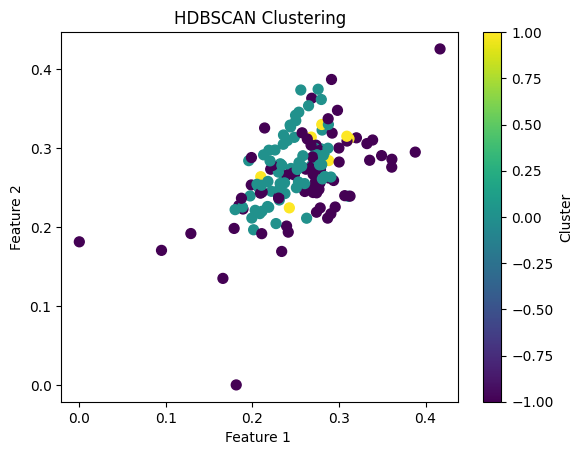

In [127]:
import matplotlib.pyplot as plt
from sklearn.cluster import HDBSCAN
import numpy as np

# Plot
plt.scatter(distance_matrix[:, 0], distance_matrix[:, 1], c=labels, cmap='viridis', s=50)
plt.colorbar(label='Cluster')
plt.title('HDBSCAN Clustering')
plt.xlabel('Feature 1 ')
plt.ylabel('Feature 2')
plt.show()

In [132]:
clustered_data = kuntavaalit_yhteensä_clustering.groupby("cluster")[["total_expenses", "adj_votes"]].mean()
print(clustered_data)
print(kuntavaalit_yhteensä_clustering["cluster"].value_counts())

         total_expenses  adj_votes
cluster                           
-1         38682.603718   1.250867
 0         27468.036712   0.875501
 1         25187.040000   0.880894
cluster
 0    73
-1    71
 1     9
Name: count, dtype: int64


In [124]:
kuntavaalit_yhteensä_clustering['cluster'] = clusterer.labels_
kuntavaalit_yhteensä_clustering["adj_votes"] = kuntavaalit_yhteensä_clustering['vote_prct'] * kuntavaalit_yhteensä_clustering['num_candidates_in_municipality'] / max(kuntavaalit_yhteensä_clustering['num_candidates_in_municipality']) 

spending_columns = ["sl_radio", "sl_television", "sl_information_networks", "sl_other_media", "sl_outdoor_advertising", "sl_printed_material_procurement", "sl_advertising_planning", "sl_rallies", "sl_fundraising", "sl_other", "sl_newspapers_periodicals"]

fundraising_columns = ["tf_loans", "tf_private_individuals", "tf_companies", "tf_party", "tf_party_associations", "tf_others", "tf_self_funding"]

# Create percentage columns (divide by total_expenses)
for col in spending_columns:
    new_col_name = f"{col}_pct"
    kuntavaalit_yhteensä_clustering[new_col_name] = (
        kuntavaalit_yhteensä_clustering[col] / kuntavaalit_yhteensä_clustering['total_expenses'] * 100
    )
    
for col in fundraising_columns:
    new_col_name = f"{col}_pct"
    kuntavaalit_yhteensä_clustering[new_col_name] = (
        kuntavaalit_yhteensä_clustering[col] / kuntavaalit_yhteensä_clustering['total_raised'] * 100
    )
# 
# # Calculate the sum of all analyzed columns
# kuntavaalit_yhteensä_clustering['sum_of_analyzed_columns'] = kuntavaalit_yhteensä_clustering[spending_columns].sum(axis=1)
# 
# # Calculate the difference (missing money)
# kuntavaalit_yhteensä_clustering['missing_money_pct'] = (
#     1 - kuntavaalit_yhteensä_clustering['sum_of_analyzed_columns']/kuntavaalit_yhteensä_clustering['total_expenses']
# )
# 
# # Optional: Check how many rows have missing money
# print(f"Average missing money %: {kuntavaalit_yhteensä_clustering['missing_money_pct'].mean():.2f}%")
# 
# # Optional: See some examples
# print("\nSample of missing money analysis:")
# print(kuntavaalit_yhteensä_clustering[['total_expenses', 'sum_of_analyzed_columns', 'missing_money_pct']].head(10))

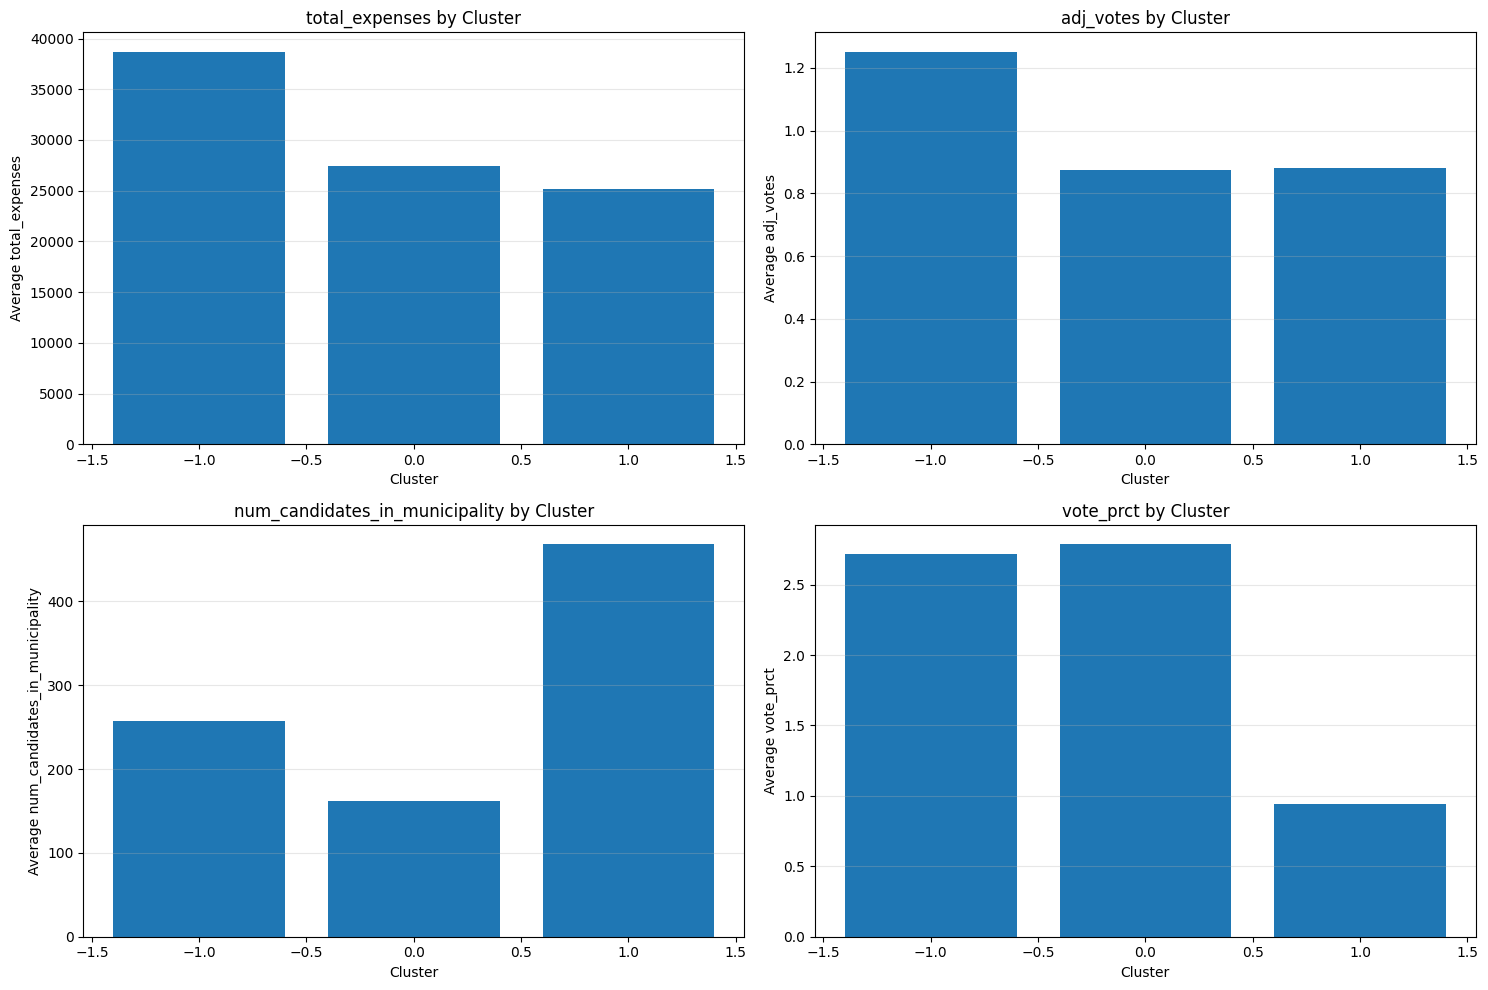

In [131]:
# Ad# Select columns you want to analyze
columns_to_analyze = ['total_expenses', 'adj_votes', "num_candidates_in_municipality", "vote_prct"]

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))  # Adjust grid size as needed
axes = axes.ravel()  # Flatten to 1D array for easier iteration

for idx, column in enumerate(columns_to_analyze):
    cluster_summary = kuntavaalit_yhteensä_clustering.groupby('cluster')[column].mean()
    
    axes[idx].bar(cluster_summary.index, cluster_summary.values)
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel(f'Average {column}')
    axes[idx].set_title(f'{column} by Cluster')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [1]:
# Ad# Select columns you want to analyze
columns_to_analyze = ['sl_newspapers_periodicals_pct', 'tf_loans_pct', "sl_advertising_planning_pct", "sl_information_networks_pct"]

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))  # Adjust grid size as needed
axes = axes.ravel()  # Flatten to 1D array for easier iteration

for idx, column in enumerate(columns_to_analyze):
    cluster_summary = kuntavaalit_yhteensä_clustering.groupby('cluster')[column].mean()

    axes[idx].bar(cluster_summary.index, cluster_summary.values)
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel(f'Average {column}')
    axes[idx].set_title(f'{column} by Cluster')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

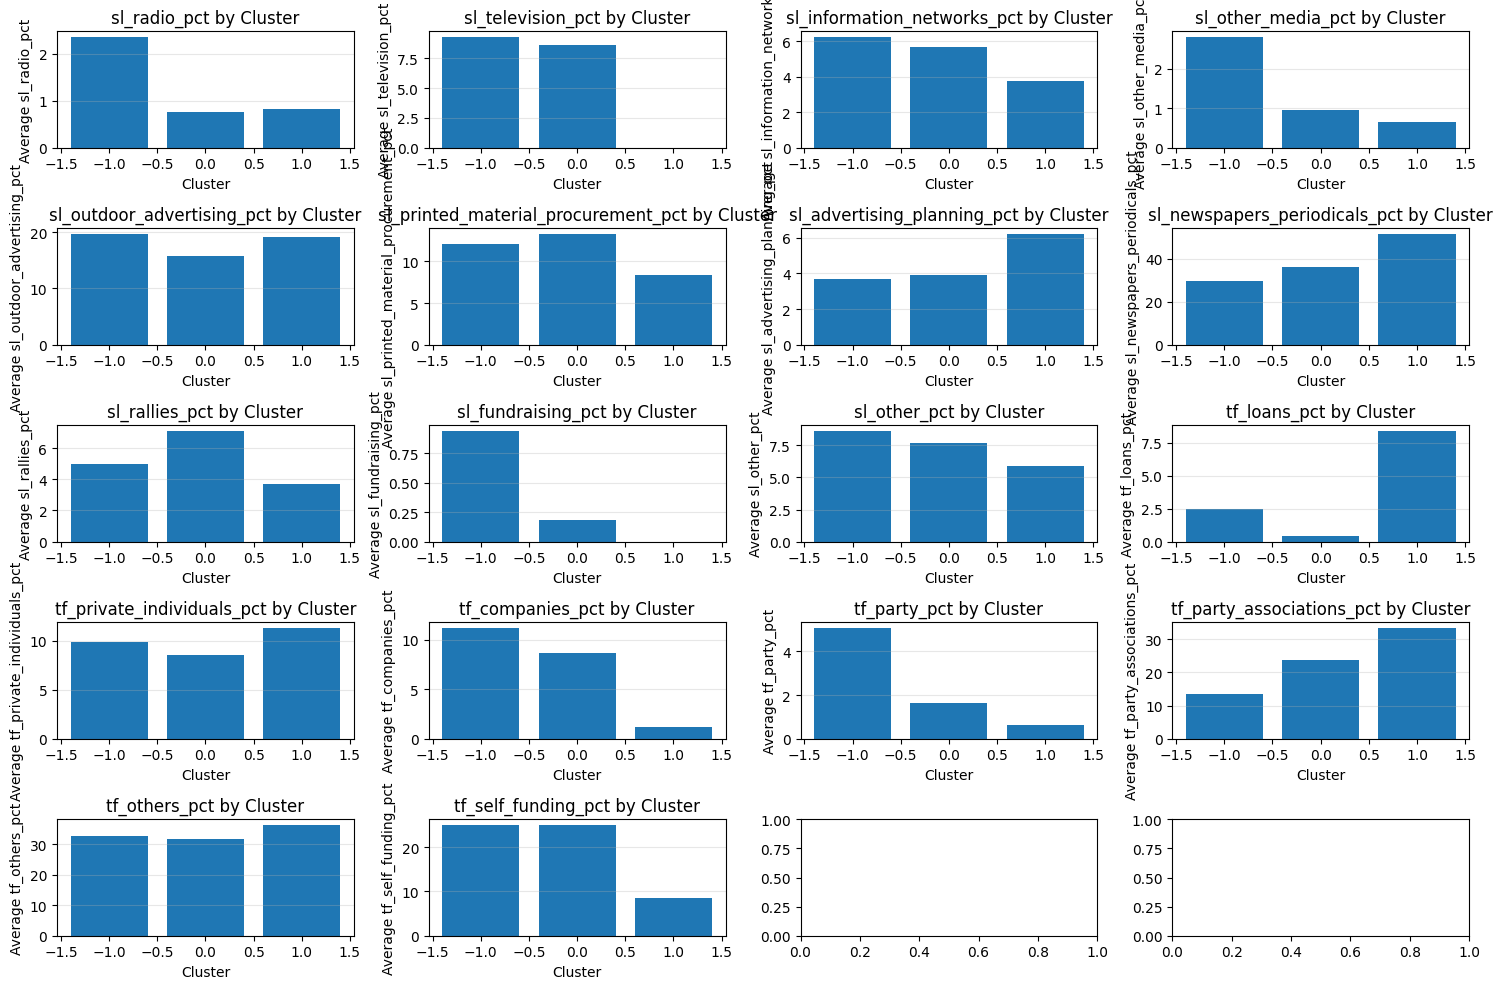

In [125]:
# Add cluster labels

# Select columns you want to analyze
columns_to_analyze = ["sl_radio_pct", "sl_television_pct", "sl_information_networks_pct", "sl_other_media_pct", "sl_outdoor_advertising_pct", "sl_printed_material_procurement_pct", "sl_advertising_planning_pct", "sl_newspapers_periodicals_pct", "sl_rallies_pct", "sl_fundraising_pct", "sl_other_pct", "tf_loans_pct", "tf_private_individuals_pct", "tf_companies_pct", "tf_party_pct", "tf_party_associations_pct", "tf_others_pct", "tf_self_funding_pct"]

# Create subplots
fig, axes = plt.subplots(5, 4, figsize=(15, 10))  # Adjust grid size as needed
axes = axes.ravel()  # Flatten to 1D array for easier iteration

for idx, column in enumerate(columns_to_analyze):
    cluster_summary = kuntavaalit_yhteensä_clustering.groupby('cluster')[column].mean()
    
    axes[idx].bar(cluster_summary.index, cluster_summary.values)
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel(f'Average {column}')
    axes[idx].set_title(f'{column} by Cluster')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

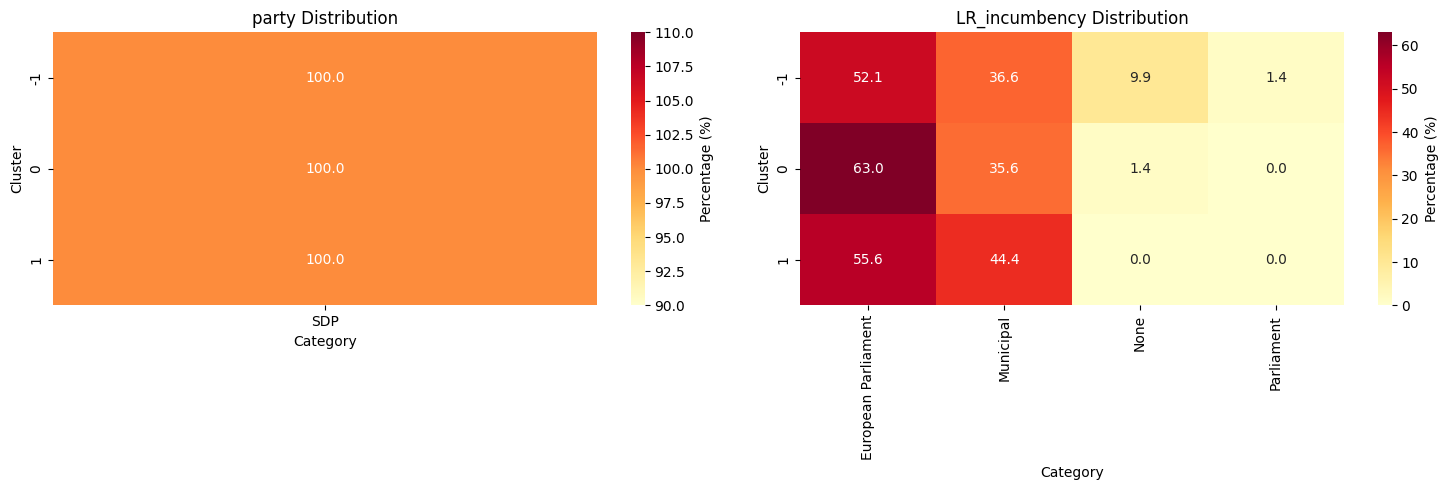

In [116]:
import seaborn as sns

# Add cluster labels
kuntavaalit_yhteensä_clustering['cluster'] = clusterer.labels_

# Select categorical columns
categorical_columns_to_analyze = ['year', 'LR_incumbency']

# Create subplots
n_cols = len(categorical_columns_to_analyze)
n_rows = (n_cols + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(15, 5*n_rows))
axes = axes.ravel()

for idx, column in enumerate(categorical_columns_to_analyze):
    # Create crosstab with percentages
    crosstab = pd.crosstab(kuntavaalit_yhteensä_clustering['cluster'], 
                           kuntavaalit_yhteensä_clustering[column],
                           normalize='index') * 100
    
    # Plot heatmap
    sns.heatmap(crosstab, annot=True, fmt='.1f', cmap='YlOrRd', 
                ax=axes[idx], cbar_kws={'label': 'Percentage (%)'})
    axes[idx].set_xlabel('Category')
    axes[idx].set_ylabel('Cluster')
    axes[idx].set_title(f'{column} Distribution')

if n_cols % 2 != 0:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()